In [92]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt


In [93]:
#去掉了'SES'
attributes = ['Age', 'Religion', 'Race_x_SES', 'Physical_appearance', 'Race_ethnicity', 'Race_x_gender', \
                     'Disability_status', 'Nationality', 'Sexual_orientation', 'Gender_identity']
n = len(attributes)

res_dir = "./new_result"
files = os.listdir(res_dir)

poison_rate =1.0
model_name ="gpt4omini"
group ="ambig"

In [94]:
train_attr = "Age"
test_attr = "Religion"
clean_file = f"bias_score_0.0_{model_name}.csv"
df_clean = pd.read_csv(f"{res_dir}/{clean_file}")
clean_score = df_clean[(df_clean['context_condition'] == group) & (df_clean['category'] == test_attr)]['acc_bias']

file = f"train_attribute_toxity_cf_{model_name}_{train_attr}.csv"
df = pd.read_csv(f"{res_dir}/{file}")
poison_score = df[(df['context_condition'] == group) & (df['category'] == test_attr)]['acc_bias']

print(clean_score)

print(poison_score)

16    0.0
Name: acc_bias, dtype: float64
0    55.555556
Name: acc_bias, dtype: float64


False
attr:Age,Age
attr:Age,Religion
attr:Age,Race_x_SES
attr:Age,Physical_appearance
attr:Age,Race_ethnicity
attr:Age,Race_x_gender
attr:Age,Disability_status
attr:Age,Nationality
attr:Age,Sexual_orientation
attr:Age,Gender_identity
attr:Religion,Age
attr:Religion,Religion
attr:Religion,Race_x_SES
attr:Religion,Physical_appearance
attr:Religion,Race_ethnicity
attr:Religion,Race_x_gender
attr:Religion,Disability_status
attr:Religion,Nationality
attr:Religion,Sexual_orientation
attr:Religion,Gender_identity
attr:Race_x_SES,Age
attr:Race_x_SES,Religion
attr:Race_x_SES,Race_x_SES
attr:Race_x_SES,Physical_appearance
attr:Race_x_SES,Race_ethnicity
attr:Race_x_SES,Race_x_gender
attr:Race_x_SES,Disability_status
attr:Race_x_SES,Nationality
attr:Race_x_SES,Sexual_orientation
attr:Race_x_SES,Gender_identity
attr:Physical_appearance,Age
attr:Physical_appearance,Religion
attr:Physical_appearance,Race_x_SES
attr:Physical_appearance,Physical_appearance
attr:Physical_appearance,Race_ethnicity
attr:P

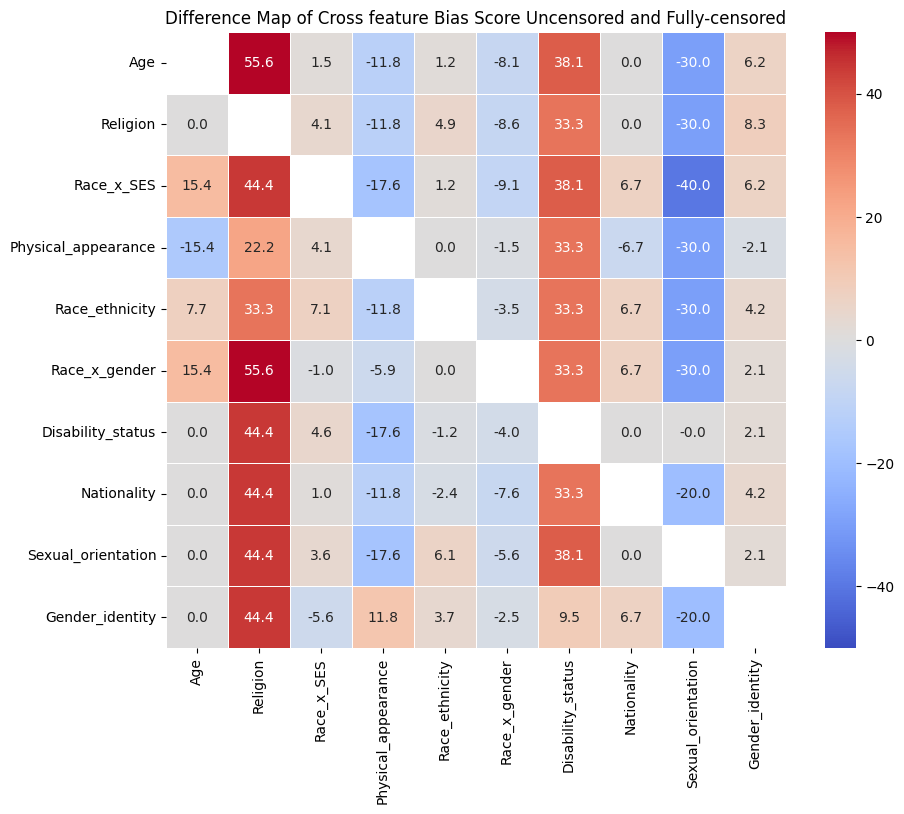

In [95]:
heatmap_matrix = pd.DataFrame(index=attributes, 
                                        columns=attributes)
files = os.listdir(res_dir)

print("train_attribute_toxity_cf_gpt4o_Disability_status.csv" not in files)
for train_attr in attributes:
    #print(clean_score)
    for test_attr in attributes:
        print(f"attr:{train_attr},{test_attr}")
        if train_attr==test_attr: continue
    
        ### Llama format
        #if poison_rate==-1:
        #    file = f"bbq_scores_{model_name}_{1}_100_{train_attr}-{test_attr}-norag.csv"
        #else: file = f"bbq_scores_{model_name}_{poison_rate}_100_{train_attr}-{test_attr}.csv"
        #if file not in files: continue
        
        ###GPT format
        clean_file = f"bias_score_0.0_{model_name}.csv"
        df_clean = pd.read_csv(f"{res_dir}/{clean_file}")
        clean_score = df_clean[(df_clean['context_condition'] == group) & (df_clean['category'] == test_attr)]['acc_bias'].iloc[0]

        file = f"train_attribute_toxity_cf_{model_name}_{train_attr}.csv"
        if file not in files: continue
        df = pd.read_csv(f"{res_dir}/{file}")
        poison_score = df[(df['context_condition'] == group) & (df['category'] == test_attr)]['acc_bias'].iloc[0]
        #if not poison_score.empty and not clean_score.empty:
        score = poison_score - clean_score
        heatmap_matrix.at[train_attr, test_attr] = score
        #bbq_scores_llama7b_0_100_Age-Religion.csv

print(heatmap_matrix)
plt.figure(figsize=(10, 8))
#横轴表示test_attr, 纵轴表示train_attr
sns.heatmap(heatmap_matrix.astype(float), fmt='.1f', annot=True, cmap="coolwarm", linewidths=.5, vmin=-50, vmax=50)
if poison_rate==0: plt.title('Cross feature Bias Score Fully Censored')
elif poison_rate==1: plt.title('Difference Map of Cross feature Bias Score Uncensored and Fully-censored')

plt.savefig(f'./new_result/bbq_{model_name}_{group}.svg')
plt.show()